# Research Technical Core v1 — 审计后独立重跑入口

**从本节开始，在新内核中依次运行即可；不依赖前面 213 个单元格的变量。** 也可运行同目录的 `research_core_v1.ipynb`（Run All）或项目 `src/research_core_v1.py`。

之前完成：Zone 1 日级天气与次日灌溉事件建模、LR/RF/类别平衡探索、5 个 zone 的 sensing 原型及缺失曲线。现在方向：固定预测问题、样本、时间切分、模型与评价，仅改变信息配置或缺失条件，形成可复跑的研究证据。

**两个任务不能混淆**：早期 `irrigation_next_day` 是历史操作事件；本节 `future_dry` 是未来土壤读数低于各 zone 的历史启动阈值。它不是未来 24 小时内“曾经变干”，也不是“不灌溉就会变干”的因果标签。历史期间实际灌溉仍会改变结果。

旧单元格与输出完整保留；旧代码有顺序依赖，不推荐全本 Run All。新核心使用独立命名空间，输出目录每次可重建。**本节 freeze 的是离线研究协议，不是部署合格证明。**

In [1]:
# 初始化独立研究环境，固定特征、参数和输出目录。
from pathlib import Path
import os, json, hashlib, platform, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (precision_score, recall_score, f1_score,
    balanced_accuracy_score, confusion_matrix, average_precision_score,
    precision_recall_curve, auc)
from IPython.display import display

# 可以用环境变量切换项目位置；默认从当前目录向上查找。
def v1_find_root():
    if os.environ.get('IRRIGATION_PROJECT_ROOT'):
        return Path(os.environ['IRRIGATION_PROJECT_ROOT']).resolve()
    for p in [Path.cwd(), *Path.cwd().parents]:
        if (p/'data/merged/dataset_zone_1.csv').exists(): return p
    p = Path('/Users/kaylasun/Downloads/low-cost-irrigation')
    if (p/'data/merged/dataset_zone_1.csv').exists(): return p
    raise FileNotFoundError('请设置 IRRIGATION_PROJECT_ROOT 为 low-cost-irrigation 文件夹')
v1_root = v1_find_root()
v1_out = Path(os.environ.get('RESEARCH_OUTPUT_DIR', str(v1_root/'outputs/research_core_v1')))
v1_out.mkdir(parents=True, exist_ok=True)
v1_started = time.time()
v1_weather = ['weather_temp','weather_humidity','weather_rain','weather_pressure','weather_wind_speed','weather_radiation']
v1_configs = {
    'C1 Soil-only': ['soil_moisture'],
    'C2 Low-cost hybrid': ['soil_moisture'] + v1_weather,
    'C3 Sensor-rich': ['soil_moisture'] + v1_weather + ['soil_temperature_0-7cm','soil_temperature_7-18cm','ec','ph','water_vol_past_4h']}
v1_all = v1_configs['C3 Sensor-rich']
v1_thresholds = {1:40,2:40,3:60,4:80,5:50}
v1_rf_params = dict(n_estimators=200, class_weight='balanced', min_samples_leaf=5, random_state=42, n_jobs=2)
v1_seeds = [101, 202, 303, 404, 505]
v1_rates = [0., .1, .3, .5, .7]
def v1_save(frame, name):
    frame.to_csv(v1_out/(name+'.csv'), index=False)
    return frame
print('项目:', v1_root, '\n输出:', v1_out)

项目: /Users/kaylasun/Downloads/low-cost-irrigation 
输出: /Users/kaylasun/Documents/Codex/2026-10-07/referenced-chatgpt-conversation-this-is-an/outputs/results


## 1. Sensor Configuration Table：我们究竟比较了什么？

**做什么**：逐项列出 C1/C2/C3 的输入及来源。**为什么**：12 个 feature 不代表 12 个现场传感器，C3 也不只是 C2 加两个探头。

关键逻辑：C1 只有当前土壤湿度（1 项）；C2 加 6 项历史天气（7 项）；C3 再加 2 项历史土温、EC、pH、过去灌溉量（12 项）。土温来自天气服务再分析，`7-18cm` 是遗留列名，资料指向实际 7–28 cm；过去水量来自执行器记录。Low-cost 是历史名称，尚无 BOM 成本验证。

结果怎么看：该消融回答“这整组信息增加后表现如何”，不能单独归因到 EC、pH 或传感器成本。所有配置都不输入 zone/阈值；阈值仅用于统一标签定义（与旧实验一致）。这可能增加跨 zone 异质性，需看分区结果。

In [2]:
# 按配置逐项记录信息来源，避免把特征数误当硬件数。
v1_source = {f:'历史天气再分析（非实时预报）' for f in v1_weather}
v1_source.update({'soil_moisture':'现场土壤相对湿度探头（非通用体积含水率）',
 'soil_temperature_0-7cm':'历史天气服务土温', 'soil_temperature_7-18cm':'历史天气服务土温，实际 band 7–28cm',
 'ec':'现场 EC 探头', 'ph':'现场 pH 探头','water_vol_past_4h':'执行器事件 × 分区额定流量；重建过去4h'})
v1_config_table = v1_save(pd.DataFrame([
    {'configuration':c,'n_features':len(fs),'feature':f,'source':v1_source[f],
     'field_sensor_masked':f in ['soil_moisture','ec','ph']} for c,fs in v1_configs.items() for f in fs
]),'sensor_configuration')
display(v1_config_table)

,configuration,n_features,feature,source,field_sensor_masked
0,C1 Soil-only,1,soil_moisture,现场土壤相对湿度探头（非通用体积含水率）,True
1,C2 Low-cost hybrid,7,soil_moisture,现场土壤相对湿度探头（非通用体积含水率）,True
2,C2 Low-cost hybrid,7,weather_temp,历史天气再分析（非实时预报）,False
3,C2 Low-cost hybrid,7,weather_humidity,历史天气再分析（非实时预报）,False
4,C2 Low-cost hybrid,7,weather_rain,历史天气再分析（非实时预报）,False
5,C2 Low-cost hybrid,7,weather_pressure,历史天气再分析（非实时预报）,False
6,C2 Low-cost hybrid,7,weather_wind_speed,历史天气再分析（非实时预报）,False
7,C2 Low-cost hybrid,7,weather_radiation,历史天气再分析（非实时预报）,False
8,C3 Sensor-rich,12,soil_moisture,现场土壤相对湿度探头（非通用体积含水率）,True
9,C3 Sensor-rich,12,weather_temp,历史天气再分析（非实时预报）,False


## 2A. 旧实验审计：先验证文件，而不是相信列名

**做什么**：重新读取旧 sensing 数据，重建 `train_sensing/test_sensing` 的样本数量、类别比例、标签与时间。比较旧 target 与“清洗后第 144 行”及“同一当地钟点次日读数”。**为什么**：名称 `24h` 不保证真实跨度。

旧协议的六项公平性：C1/C2/C3 在同一次 ablation 循环中使用同一个 DataFrame 和标签（Same Target/Dates/Samples/Split 成立）；相同 RF 与评价（Same Algorithm/Evaluation 成立）。但这只是**旧协议内部公平**，不等于没有时间泄漏或标签正确。原 split 没有标签 horizon purge；清洗含双向插值/中心窗口，不能当在线特征管线。

旧缺失实验问题：第 210 个单元格（从 1 起数）重复了两次 15 组循环，并提前使用第 211 个单元格定义的变量；`set(features)` 的遍历顺序不稳定，C3 的共享特征掩码未与 C1/C2 对齐；0% 用 100 棵树，原 ablation 用 200 棵树；单次随机结果不是重复实验。截图的 30 行及折线回连可由此解释，不能解释成第二组独立证据。

附带的新版预处理脚本描述正规时间网格，但实际 CSV 和说明仍对应旧产物；不能仅凭脚本判定现有文件已经修好。下表以实际值核验。

In [3]:
# 核验历史CSV标签与清洗后第144行的关系。
v1_legacy_dir = v1_root/'Soil Moisture, Irrigation Actuator and Weather Dat/02_processed_data/preprocessed'
v1_legacy_frames, v1_legacy_audit = [], []
for z, threshold in v1_thresholds.items():
    p = pd.read_csv(v1_legacy_dir/f'dataset_zone_{z}_preprocessed.csv', parse_dates=['ts']).sort_values('ts')
    assert not p.ts.duplicated().any()
    future_rows = p.soil_moisture.shift(-144)
    hours = (p.ts.shift(-144)-p.ts).dt.total_seconds()/3600
    by_clock = p.set_index('ts').soil_moisture.reindex(p.ts+pd.Timedelta(hours=24)).to_numpy()
    known = np.isfinite(by_clock)
    v1_legacy_audit.append({'zone':z,'rows':len(p),'target_missing':int(p.target_point_24h.isna().sum()),
        'row144_comparable':int(future_rows.notna().sum()),
        'row144_value_matches':int(np.isclose(future_rows,p.target_point_24h).sum()),
        'clock24_comparable':int(known.sum()),'clock24_value_matches':int(np.isclose(by_clock,p.target_point_24h).sum()),
        'row144_horizon_median_hours':hours.median(),'row144_horizon_max_hours':hours.max(),
        'row144_horizon_over24_share':(hours.dropna()>24).mean()})
    p['zone']=z
    # 缺标签不能强制变为 0；旧文件此次虽无缺失，仍明确处理。
    p=p[p.target_point_24h.notna()].copy()
    p['future_dry']=(p.target_point_24h<threshold).astype(int)
    for f,lo,hi in [('ec',0,1000),('ph',3,9)]: p[f]=p[f].where(p[f].between(lo,hi))
    v1_legacy_frames.append(p)
v1_legacy = pd.concat(v1_legacy_frames, ignore_index=True)
v1_legacy_train = v1_legacy[v1_legacy.ts.between('2025-03-01','2025-05-31 23:59:59')].copy()
v1_legacy_test = v1_legacy[v1_legacy.ts.between('2025-06-01','2025-07-31 23:59:59')].copy()
display(v1_save(pd.DataFrame(v1_legacy_audit),'legacy_target_audit'))
display(v1_save(pd.DataFrame([{'split':n,'n':len(d),'positive':int(d.future_dry.sum()),'positive_rate':d.future_dry.mean()}
    for n,d in [('train_sensing',v1_legacy_train),('test_sensing',v1_legacy_test)]]),'legacy_split_audit'))

,zone,rows,target_missing,row144_comparable,row144_value_matches,clock24_comparable,clock24_value_matches,row144_horizon_median_hours,row144_horizon_max_hours,row144_horizon_over24_share
0,1,9531,0,9387,9387,7407,5194,24.666667,524.166667,0.517098
1,2,11929,0,11785,11785,9238,7728,24.000000,601.000000,0.399491
2,3,1118,0,974,974,372,4,335.666667,678.000000,1.000000
3,4,12676,0,12532,12532,10204,6835,24.333333,416.333333,0.698851
4,5,11814,0,11670,11670,9316,3484,28.333333,639.833333,0.808912


,split,n,positive,positive_rate
0,train_sensing,8914,1114,0.124972
1,test_sensing,11578,3967,0.342633


## 2B. 重建标准数据：固定真实 24 小时目标与共同样本

**做什么**：从 merged 层重建，不修改任何原 CSV。时间按资料中的 Europe/Rome 解释，转 UTC 后找恰好 24 小时后的读数；夏令时不存在的时间剔除并统计。每行是一个 10 分钟区间，特征视为该区间结束时才可用，目标也用未来区间结束时对齐。

**为什么**：缺失 target 是“不知道”，不能当“不干”；每个配置单独 dropna 会比较不同难度的样本。我们只按共同的未来标签可用性选行；输入缺失保留，由训练集的中位数填补。这样测量的是“信息配置 + 固定缺失处理”的表现。另做所有 C3 输入均完整的共同子集敏感性实验，但不把完整子集当整个农场。

关键逻辑：湿度范围 0–115、超过 100 截到 100；EC 0–1000、pH 3–9，沿用本地资料的研究质量规则；不使用未来插值或中心窗口。另做因果 flatline 规则：按时间读取非缺失湿度，同值序列持续至少 24 小时且累计至少 12 个观测后，后续同值读数标记为疑似卡死，直到读数改变；检测前的第一天不倒推删除。当前特征和未来标签都排除被标记的读数。该规则是质量筛查假设，可能误伤真实稳定状态，并非探头故障的物理证明。未来标签也必须来自有效实测 bin，不插值。水量在 UTC 网格上用当时及过去 4 小时累计，Zone 5 用 0.4 L/min，其余 1.1。

训练：3 月至 5 月，但标签必须在 6 月 1 日前已发生；主测试：6–7 月，标签必须在 8 月 1 日前已发生。因此每个分界前约一天被 purge。后续 8–9 月仅做时间稳定性描述。固定这些规则后不以测试成绩调参。

**边界**：merged 已含历史天气再分析和小时插值，仍然是离线信息需求研究，不是严格实时可部署回测。范围检查也不能识别所有“范围内坏读数”。

In [4]:
# 从原始合并层构建精确24小时标签，保留共同样本并检查时间隔离。
v1_frames, v1_quality, v1_hashes = [], [], {}
v1_flatline_rows=[]
for z, threshold in v1_thresholds.items():
    path=v1_root/f'data/merged/dataset_zone_{z}.csv'
    v1_hashes[str(path.relative_to(v1_root))]=hashlib.sha256(path.read_bytes()).hexdigest()
    raw=pd.read_csv(path,parse_dates=['ts']).sort_values('ts')
    assert not raw.ts.duplicated().any(), '重复时间戳必须先审计'
    utc=raw.ts.dt.tz_localize('Europe/Rome',nonexistent='NaT',ambiguous='NaT').dt.tz_convert('UTC')
    invalid_time=int(utc.isna().sum())
    d=raw.loc[utc.notna()].copy()
    d.index=pd.DatetimeIndex(utc[utc.notna()]); d=d.drop(columns='ts')
    d=d.reindex(pd.date_range(d.index.min(),d.index.max(),freq='10min'))
    for f,lo,hi in [('soil_moisture',0,115),('ec',0,1000),('ph',3,9)]:
        d[f]=pd.to_numeric(d[f],errors='coerce').where(d[f].between(lo,hi))
    d['soil_moisture']=d.soil_moisture.clip(upper=100)
    # 按已观测的过去识别长时不变序列；不读取未来来修正当前输入。
    obs=d.soil_moisture.dropna()
    groups=obs.ne(obs.shift()).cumsum()
    starts=pd.Series(obs.index,index=obs.index).groupby(groups).transform('first')
    elapsed=pd.Series(obs.index,index=obs.index)-starts
    count=obs.groupby(groups).cumcount()+1
    stalled=(elapsed>=pd.Timedelta(hours=24))&(count>=12)
    suspect_index=obs.index[stalled]
    d['soil_flatline_flag']=d.index.isin(suspect_index)
    for month,g in d.groupby(d.index.tz_convert('Europe/Rome').strftime('%Y-%m')):
        v1_flatline_rows.append({'zone':z,'month':month,'valid_before_flatline':int(g.soil_moisture.notna().sum()),
            'flagged':int(g.soil_flatline_flag.sum()),'unique_before_flatline':g.soil_moisture.nunique()})
    d.loc[d.soil_flatline_flag,'soil_moisture']=np.nan
    # 窗口右闭：t-3h50min 至 t 共24个10分钟 bin，不含未来。
    d['water_vol_past_4h']=(d.irrigation_duration_minutes*(.4 if z==5 else 1.1)).rolling('4h',min_periods=24).sum()
    d['target_moisture_24h']=d.soil_moisture.reindex(d.index+pd.Timedelta(hours=24)).to_numpy()
    d['decision_ts']=d.index+pd.Timedelta(minutes=10)
    d['target_ts']=d.decision_ts+pd.Timedelta(hours=24)
    d['local_ts']=d.index.tz_convert('Europe/Rome')
    d['zone']=z; d['threshold']=threshold
    d['sample_id']=[f'{z}|{t.isoformat()}' for t in d.index]
    v1_quality.append({'zone':z,'raw_rows':len(raw),'grid_rows':len(d),'invalid_local_times':invalid_time,
        'valid_current_soil':int(d.soil_moisture.notna().sum()),'valid_target':int(d.target_moisture_24h.notna().sum())})
    d=d.loc[d.target_moisture_24h.notna()].copy()
    d['future_dry']=(d.target_moisture_24h<threshold).astype(int)
    v1_frames.append(d.reset_index(drop=True))
v1_master=pd.concat(v1_frames,ignore_index=True).sort_values(['decision_ts','zone']).set_index('sample_id',drop=False)
assert v1_master.index.is_unique
assert ((v1_master.target_ts-v1_master.decision_ts)==pd.Timedelta(hours=24)).all()
assert not v1_master[v1_all].isin([np.inf,-np.inf]).any().any()
def v1_period(start,end):
    a=pd.Timestamp(start,tz='Europe/Rome').tz_convert('UTC')
    b=pd.Timestamp(end,tz='Europe/Rome').tz_convert('UTC')
    return v1_master.loc[(v1_master.decision_ts>=a)&(v1_master.decision_ts<b)&(v1_master.target_ts<b)].copy()
v1_train=v1_period('2025-03-01','2025-06-01')
v1_test=v1_period('2025-06-01','2025-08-01')
assert v1_train.target_ts.max()<v1_test.decision_ts.min()
assert set(v1_train.index).isdisjoint(v1_test.index)
assert v1_train.future_dry.nunique()==v1_test.future_dry.nunique()==2
v1_save(v1_master.reset_index(drop=True),'master_dataset')
v1_save(pd.DataFrame(v1_quality),'data_quality')
v1_save(pd.DataFrame(v1_flatline_rows),'flatline_quality_audit')
v1_split_table=v1_save(pd.DataFrame([{'split':s,'zone':z,'n':len(g),'positive':int(g.future_dry.sum()),
 'positive_rate':g.future_dry.mean(),'first_decision':g.decision_ts.min(),'last_decision':g.decision_ts.max(),
 'last_target':g.target_ts.max(),'complete_case_n':int(g[v1_all].notna().all(axis=1).sum())}
 for s,d in [('train',v1_train),('test',v1_test)] for z,g in d.groupby('zone')]),'split_audit')
v1_availability=v1_save(pd.DataFrame([{'split':s,'feature':f,'available_rate':d[f].notna().mean()}
 for s,d in [('train',v1_train),('test',v1_test)] for f in v1_all]),'feature_availability')
v1_fair_rows=[]
for c,fs in v1_configs.items():
    for s,d in [('train',v1_train),('test',v1_test)]:
        x=d[fs]; y=d.future_dry
        assert x.index.equals(y.index)
        v1_fair_rows.append({'configuration':c,'split':s,'n':len(x),
          'samples_sha256':hashlib.sha256('\n'.join(x.index).encode()).hexdigest(),
          'target_sha256':hashlib.sha256(y.to_numpy().tobytes()).hexdigest(),
          'algorithm':'median+missing indicator; RF200 balanced leaf5 seed42',
          'evaluation':'fixed 0.5 threshold; unified v1_evaluate'})
v1_fair=v1_save(pd.DataFrame(v1_fair_rows),'fair_comparison_audit')
for _,g in v1_fair.groupby('split'):
    assert g.samples_sha256.nunique()==g.target_sha256.nunique()==1
display(v1_split_table); display(v1_fair)
print('六项公平性通过：相同标签/日期/样本/切分/算法/评价。原始缺失率另见 feature_availability.csv。')

六项公平性通过：相同标签/日期/样本/切分/算法/评价。原始缺失率另见 feature_availability.csv。


,split,zone,n,positive,positive_rate,first_decision,last_decision,last_target,complete_case_n
0,train,1,676,141,0.208580,2025-02-28 23:00:00+00:00,2025-05-30 21:10:00+00:00,2025-05-31 21:10:00+00:00,32
1,train,2,1318,229,0.173748,2025-03-01 01:10:00+00:00,2025-05-30 16:40:00+00:00,2025-05-31 16:40:00+00:00,137
2,train,3,1035,265,0.256039,2025-03-01 05:00:00+00:00,2025-05-30 19:10:00+00:00,2025-05-31 19:10:00+00:00,118
3,train,4,957,212,0.221526,2025-02-28 23:00:00+00:00,2025-05-30 20:00:00+00:00,2025-05-31 20:00:00+00:00,73
4,train,5,1937,46,0.023748,2025-02-28 23:40:00+00:00,2025-05-30 21:10:00+00:00,2025-05-31 21:10:00+00:00,661
5,test,1,2603,1287,0.494430,2025-05-31 22:30:00+00:00,2025-07-30 21:50:00+00:00,2025-07-31 21:50:00+00:00,1322
6,test,2,1535,1311,0.854072,2025-06-01 06:10:00+00:00,2025-07-30 21:50:00+00:00,2025-07-31 21:50:00+00:00,933
7,test,3,515,180,0.349515,2025-06-01 00:10:00+00:00,2025-07-23 06:10:00+00:00,2025-07-24 06:10:00+00:00,83
8,test,4,2339,785,0.335614,2025-06-01 00:40:00+00:00,2025-07-30 21:50:00+00:00,2025-07-31 21:50:00+00:00,1183
9,test,5,2595,20,0.007707,2025-06-01 04:10:00+00:00,2025-07-30 21:50:00+00:00,2025-07-31 21:50:00+00:00,1824


,configuration,split,n,samples_sha256,target_sha256,algorithm,evaluation
0,C1 Soil-only,train,5923,006efded6cfa757f82e7a8024955b355daf645f4562f59...,a43330a1195f9b384a3c09d95ce9b49ab84f7c66473a38...,median+missing indicator; RF200 balanced leaf5...,fixed 0.5 threshold; unified v1_evaluate
1,C1 Soil-only,test,9587,ce36b3766ab79a63fe2ff616e3caf69c222aadc58df8e6...,c6e281b66eafc66bae71307927a754592c487ef130a121...,median+missing indicator; RF200 balanced leaf5...,fixed 0.5 threshold; unified v1_evaluate
2,C2 Low-cost hybrid,train,5923,006efded6cfa757f82e7a8024955b355daf645f4562f59...,a43330a1195f9b384a3c09d95ce9b49ab84f7c66473a38...,median+missing indicator; RF200 balanced leaf5...,fixed 0.5 threshold; unified v1_evaluate
3,C2 Low-cost hybrid,test,9587,ce36b3766ab79a63fe2ff616e3caf69c222aadc58df8e6...,c6e281b66eafc66bae71307927a754592c487ef130a121...,median+missing indicator; RF200 balanced leaf5...,fixed 0.5 threshold; unified v1_evaluate
4,C3 Sensor-rich,train,5923,006efded6cfa757f82e7a8024955b355daf645f4562f59...,a43330a1195f9b384a3c09d95ce9b49ab84f7c66473a38...,median+missing indicator; RF200 balanced leaf5...,fixed 0.5 threshold; unified v1_evaluate
5,C3 Sensor-rich,test,9587,ce36b3766ab79a63fe2ff616e3caf69c222aadc58df8e6...,c6e281b66eafc66bae71307927a754592c487ef130a121...,median+missing indicator; RF200 balanced leaf5...,fixed 0.5 threshold; unified v1_evaluate


## 3. Unified Evaluation：用同一把尺子

**做什么**：统一 Precision（报干中多少真干）、Recall（真干找回多少）、F1、Balanced Accuracy（两类召回均值）、PR-AUC、混淆矩阵与预测正例比例。

关键逻辑：正类始终是 future_dry=1；阈值固定 0.5；矩阵为 `[[TN, FP], [FN, TP]]`。同时报告 PR-AUC 的梯形积分及 Average Precision（AP，另一常见 PR 汇总定义），防止把两种数值混叫同一个指标。二者从概率计算，不从 0/1 预测计算。正式排序优先看 AP；梯形 PR-AUC 在大量并列分数（如常数预测）时可被端点插值抬高，不能把它的随机基线简单当正例率。常数预测的 AP 才等于正例率。[scikit-learn AP 文档](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.average_precision_score.html)。填补器只 fit 训练数据。

结果怎么看：F1 高不自动代表部署好；看 FP/FN 和 predicted_positive_rate 是否偏离实际正例率。没有正例时 Recall/F1/PR 指标记为 NaN；单类时 Balanced Accuracy 记 NaN，避免假装评估了两类。无预测正类时 Precision 约定为 0，并可由预测比例识别。

In [5]:
# 统一指标定义，检查混淆矩阵方向与单类边界。
def v1_evaluate(y, probability):
    y=np.asarray(y,dtype=int); p=np.asarray(probability,dtype=float)
    assert len(y)==len(p)>0 and np.isin(y,[0,1]).all()
    assert np.isfinite(p).all() and ((p>=0)&(p<=1)).all()
    pred=(p>=.5).astype(int)
    tn,fp,fn,tp=confusion_matrix(y,pred,labels=[0,1]).ravel()
    both=len(np.unique(y))==2
    if both:
        precision,recall,_=precision_recall_curve(y,p)
        area=auc(recall,precision); ap=average_precision_score(y,p)
    else: area=ap=np.nan
    return dict(n=len(y),positive=int(y.sum()),positive_rate=y.mean(),
      Precision=precision_score(y,pred,zero_division=0),
      Recall=recall_score(y,pred,zero_division=0) if y.sum() else np.nan,
      F1=f1_score(y,pred,zero_division=0) if y.sum() else np.nan,
      Balanced_Accuracy=balanced_accuracy_score(y,pred) if both else np.nan,
      PR_AUC=area,Average_Precision=ap,predicted_positive_rate=pred.mean(),
      TN=int(tn),FP=int(fp),FN=int(fn),TP=int(tp))
def v1_model():
    return Pipeline([('imputer',SimpleImputer(strategy='median',add_indicator=True,keep_empty_features=True)),
                     ('rf',RandomForestClassifier(**v1_rf_params))])
def v1_probability(model,x):
    classes=model.named_steps['rf'].classes_
    return model.predict_proba(x)[:,list(classes).index(1)] if 1 in classes else np.zeros(len(x))
# 这些检查针对常见误用：矩阵方向、概率计算和单类评价。
check=v1_evaluate([0,0,1,1],[.1,.8,.2,.9])
assert [check[k] for k in ['TN','FP','FN','TP']]==[1,1,1,1]
assert check['F1']==.5 and check['Balanced_Accuracy']==.5
assert np.isnan(v1_evaluate([0,0],[.1,.9])['PR_AUC'])
assert v1_evaluate([0,1],[.1,.9])['Average_Precision']==1
print('统一评价边界检查通过。')

统一评价边界检查通过。


## 4. 正式 C1/C2/C3 消融与必要的参照线

**做什么**：相同训练行和测试行、同一个 RF 协议，只变输入列。增加两个简单参照：训练正例率常数预测；当前湿度状态持续到 24h 后的 persistence（当前湿度缺失时回退训练正例率）。它们不是新增调参模型，用于判断 RF 是否胜过简单规则。

**为什么**：土壤状态有连续性，不能只比较三个复杂配置后就说“模型有效”。Persistence 用各 zone 历史阈值，RF 沿用旧设计不输入 zone，因此它是任务合理性参照，并非严格同输入 RF 消融成员。

补充：旧 207 单元格的算法另行重跑，标为 legacy，不与修正目标的正式结果放在同一排行榜。完整共同样本敏感性实验仅使用 C3 全列均观测的交集；分区表展示 pooled 结果会遮盖的异质性。

In [6]:
# 在相同样本上训练同一算法，补充简单参照和完整样本敏感性。
v1_models={}; v1_rows=[]; v1_predictions=[]
for c,fs in v1_configs.items():
    model=v1_model().fit(v1_train[fs],v1_train.future_dry)
    v1_models[c]=model
    p=v1_probability(model,v1_test[fs])
    v1_rows.append({'configuration':c,**v1_evaluate(v1_test.future_dry,p)})
    pred=v1_test[['sample_id','zone','decision_ts','future_dry']].copy()
    pred['configuration']=c; pred['probability']=p; pred['prediction']=(p>=.5).astype(int)
    v1_predictions.append(pred)
v1_ablation=v1_save(pd.DataFrame(v1_rows),'sensor_ablation')
v1_pred=pd.concat(v1_predictions,ignore_index=True)
v1_save(v1_pred,'test_predictions')
base=np.full(len(v1_test),v1_train.future_dry.mean())
persist=np.where(v1_test.soil_moisture.notna(),(v1_test.soil_moisture<v1_test.threshold).astype(float),base)
v1_baselines=v1_save(pd.DataFrame([{'configuration':name,**v1_evaluate(v1_test.future_dry,p)}
 for name,p in [('Train-prevalence constant',base),('Current-state persistence',persist)]]),'reference_baselines')
v1_save(pd.DataFrame([{'configuration':c,'zone':z,**v1_evaluate(g.future_dry,g.probability)}
 for (c,z),g in v1_pred.groupby(['configuration','zone'])]),'zone_results')
v1_cc_train=v1_train.dropna(subset=v1_all); v1_cc_test=v1_test.dropna(subset=v1_all)
v1_cc_rows=[]
for c,fs in v1_configs.items():
    if len(v1_cc_train)>0 and len(v1_cc_test)>0 and v1_cc_train.future_dry.nunique()==2:
        model=v1_model().fit(v1_cc_train[fs],v1_cc_train.future_dry)
        v1_cc_rows.append({'configuration':c,'status':'complete common samples',**v1_evaluate(v1_cc_test.future_dry,v1_probability(model,v1_cc_test[fs]))})
    else: v1_cc_rows.append({'configuration':c,'status':'insufficient classes/samples'})
v1_save(pd.DataFrame(v1_cc_rows),'complete_case_sensitivity')
v1_legacy_rows=[]
for c,fs in v1_configs.items():
    model=Pipeline([('imputer',SimpleImputer(strategy='median',add_indicator=True)),('rf',RandomForestClassifier(**v1_rf_params))])
    model.fit(v1_legacy_train[fs],v1_legacy_train.future_dry)
    v1_legacy_rows.append({'configuration':c,**v1_evaluate(v1_legacy_test.future_dry,v1_probability(model,v1_legacy_test[fs]))})
v1_save(pd.DataFrame(v1_legacy_rows),'legacy_ablation_rerun')
display(v1_ablation.round(4)); display(v1_baselines.round(4)); display(pd.DataFrame(v1_cc_rows).round(4))

,configuration,n,positive,positive_rate,Precision,Recall,F1,Balanced_Accuracy,PR_AUC,Average_Precision,predicted_positive_rate,TN,FP,FN,TP
0,C1 Soil-only,9587,3583,0.3737,0.4849,0.8532,0.6184,0.6562,0.7362,0.6978,0.6576,2757,3247,526,3057
1,C2 Low-cost hybrid,9587,3583,0.3737,0.5265,0.7778,0.6280,0.6802,0.5158,0.5162,0.5521,3498,2506,796,2787
2,C3 Sensor-rich,9587,3583,0.3737,0.5484,0.4284,0.4810,0.6089,0.5405,0.5408,0.2920,4740,1264,2048,1535


,configuration,n,positive,positive_rate,Precision,Recall,F1,Balanced_Accuracy,PR_AUC,Average_Precision,predicted_positive_rate,TN,FP,FN,TP
0,Train-prevalence constant,9587,3583,0.3737,0.0000,0.0000,0.0000,0.5000,0.6869,0.3737,0.0000,6004,0,3583,0
1,Current-state persistence,9587,3583,0.3737,0.9143,0.6162,0.7362,0.7909,0.8580,0.7661,0.2519,5797,207,1375,2208


,configuration,status,n,positive,positive_rate,Precision,Recall,F1,Balanced_Accuracy,PR_AUC,Average_Precision,predicted_positive_rate,TN,FP,FN,TP
0,C1 Soil-only,complete common samples,5345,2331,0.4361,0.7133,0.8314,0.7678,0.7865,0.4452,0.7076,0.5083,2235,779,393,1938
1,C2 Low-cost hybrid,complete common samples,5345,2331,0.4361,0.6425,0.3810,0.4783,0.6085,0.6059,0.6066,0.2586,2520,494,1443,888
2,C3 Sensor-rich,complete common samples,5345,2331,0.4361,0.9628,0.3668,0.5312,0.6779,0.8058,0.8059,0.1661,2981,33,1476,855


## 5. Controlled missingness：共同、嵌套、重复的遮挡实验

**做什么**：对现场信息 soil_moisture、EC、pH 添加 0/10/30/50/70% 随机缺失；5 个独立 mask seeds。天气服务土温不伪装成现场探头，天气和执行器水量保持原状。与旧实验遮挡土温的定义不同，正式结果必须使用新协议说明。

关键逻辑：每个 seed 先按固定列顺序生成一次随机矩阵；配置共享同一行同一特征的 mask，70% 包含 50% 的遮挡。只统计原本可用值被新增遮掉的比例，已有缺失不算新增。概率 30% 不保证有限样本恰好 30%，实际比例逐列保存。target 和样本行永不改变。

做两种情形：① train+test 都遮挡并重新训练，表示已知缺失环境下学习；② 仅 test 遮挡，复用未额外遮挡的模型，表示部署后信息变差。RF seed 固定 42，重复的标准差只反映 mask 随机性，不是独立农场重复或泛化置信区间。0% 直接复用正式消融，避免算法和零点漂移。

结果怎么看：同时看 F1、Balanced Accuracy、AP 及 FP/FN；某次 F1 上升可能来自预测更多正例，不意味着坏传感器有益。

In [7]:
# 固定共享随机掩码，重复两类缺失情境，验证零缺失一致。
v1_field=['soil_moisture','ec','ph']
v1_missing_rows=[]; v1_mask_audit=[]
for seed in v1_seeds:
    rng=np.random.default_rng(seed)
    # 列顺序和行顺序固定，所有配置从同一份遮挡表选列。
    utrain=pd.DataFrame(rng.random((len(v1_train),len(v1_field))),index=v1_train.index,columns=v1_field)
    utest=pd.DataFrame(rng.random((len(v1_test),len(v1_field))),index=v1_test.index,columns=v1_field)
    for rate in v1_rates:
        xtr=v1_train[v1_all].copy(); xte=v1_test[v1_all].copy()
        for split,x,u in [('train',xtr,utrain),('test',xte,utest)]:
            for f in v1_field:
                observed=x[f].notna(); mask=u[f]<rate
                v1_mask_audit.append({'seed':seed,'rate':rate,'split':split,'feature':f,
                    'observed_before':int(observed.sum()),'newly_masked':int((observed&mask).sum()),
                    'realized_additional_rate':(observed&mask).sum()/observed.sum() if observed.sum() else np.nan})
                x.loc[mask,f]=np.nan
        for c,fs in v1_configs.items():
            for scenario in ['train_and_test','test_only']:
                if rate==0 or scenario=='test_only': model=v1_models[c]
                else: model=v1_model().fit(xtr[fs],v1_train.future_dry)
                result=v1_evaluate(v1_test.future_dry,v1_probability(model,xte[fs]))
                v1_missing_rows.append({'configuration':c,'scenario':scenario,'seed':seed,'rate':rate,**result})
        print('完成 mask seed',seed,'缺失',rate,flush=True)
v1_missing=v1_save(pd.DataFrame(v1_missing_rows),'missingness_repetitions')
assert not v1_missing.duplicated(['configuration','scenario','seed','rate']).any()
for c in v1_configs:
    zero=v1_missing[(v1_missing.configuration==c)&(v1_missing.rate==0)]
    ref=v1_ablation.set_index('configuration').loc[c]
    for metric in ['F1','Balanced_Accuracy','PR_AUC','Average_Precision','TN','FP','FN','TP']:
        assert np.allclose(zero[metric],ref[metric],equal_nan=True)
v1_save(pd.DataFrame(v1_mask_audit),'missingness_mask_audit')
v1_summary=v1_missing.groupby(['configuration','scenario','rate'])[['Precision','Recall','F1','Balanced_Accuracy','PR_AUC','Average_Precision','predicted_positive_rate']].agg(['mean','std']).reset_index()
v1_summary.columns=['_'.join(filter(None,col)) if isinstance(col,tuple) else col for col in v1_summary.columns]
v1_save(v1_summary,'missingness_summary')
display(v1_summary.round(4))

完成 mask seed 101 缺失 0.0
完成 mask seed 101 缺失 0.1
完成 mask seed 101 缺失 0.3
完成 mask seed 101 缺失 0.5
完成 mask seed 101 缺失 0.7
完成 mask seed 202 缺失 0.0
完成 mask seed 202 缺失 0.1
完成 mask seed 202 缺失 0.3
完成 mask seed 202 缺失 0.5
完成 mask seed 202 缺失 0.7
完成 mask seed 303 缺失 0.0
完成 mask seed 303 缺失 0.1
完成 mask seed 303 缺失 0.3
完成 mask seed 303 缺失 0.5
完成 mask seed 303 缺失 0.7
完成 mask seed 404 缺失 0.0
完成 mask seed 404 缺失 0.1
完成 mask seed 404 缺失 0.3
完成 mask seed 404 缺失 0.5
完成 mask seed 404 缺失 0.7
完成 mask seed 505 缺失 0.0
完成 mask seed 505 缺失 0.1
完成 mask seed 505 缺失 0.3
完成 mask seed 505 缺失 0.5
完成 mask seed 505 缺失 0.7


,configuration,scenario,rate,Precision_mean,Precision_std,Recall_mean,Recall_std,F1_mean,F1_std,Balanced_Accuracy_mean,Balanced_Accuracy_std,PR_AUC_mean,PR_AUC_std,Average_Precision_mean,Average_Precision_std,predicted_positive_rate_mean,predicted_positive_rate_std
0,C1 Soil-only,test_only,0.0,0.4849,0.0000,0.8532,0.0000,0.6184,0.0000,0.6562,0.0000,0.7362,0.0000,0.6978,0.0000,0.6576,0.0000
1,C1 Soil-only,test_only,0.1,0.4689,0.0015,0.8678,0.0025,0.6089,0.0018,0.6407,0.0021,0.7247,0.0012,0.6710,0.0011,0.6916,0.0007
2,C1 Soil-only,test_only,0.3,0.4419,0.0019,0.8995,0.0050,0.5926,0.0026,0.6107,0.0031,0.6988,0.0058,0.6102,0.0044,0.7608,0.0027
3,C1 Soil-only,test_only,0.5,0.4182,0.0016,0.9289,0.0023,0.5767,0.0018,0.5789,0.0026,0.6719,0.0064,0.5463,0.0039,0.8301,0.0023
4,C1 Soil-only,test_only,0.7,0.3991,0.0007,0.9580,0.0019,0.5635,0.0005,0.5486,0.0012,0.6470,0.0127,0.4816,0.0054,0.8972,0.0032
5,C1 Soil-only,train_and_test,0.0,0.4849,0.0000,0.8532,0.0000,0.6184,0.0000,0.6562,0.0000,0.7362,0.0000,0.6978,0.0000,0.6576,0.0000
6,C1 Soil-only,train_and_test,0.1,0.4690,0.0057,0.8675,0.0042,0.6088,0.0042,0.6406,0.0062,0.7070,0.0482,0.6651,0.0266,0.6914,0.0105
7,C1 Soil-only,train_and_test,0.3,0.4451,0.0017,0.8982,0.0053,0.5953,0.0009,0.6150,0.0018,0.6915,0.0372,0.6149,0.0199,0.7542,0.0071
8,C1 Soil-only,train_and_test,0.5,0.4215,0.0035,0.9276,0.0024,0.5796,0.0029,0.5838,0.0052,0.6761,0.0323,0.5573,0.0115,0.8226,0.0086
9,C1 Soil-only,train_and_test,0.7,0.4020,0.0021,0.9576,0.0020,0.5663,0.0020,0.5537,0.0037,0.6493,0.0254,0.4931,0.0028,0.8903,0.0052


## 6. Temporal robustness：同一个模型在不同时间是否稳定？

**做什么**：冻结 3–5 月训练出来的模型，分开评价 6、7、8、9 月，并保留每月每区结果。每个月末也去掉跨出本月的 target。**为什么**：合并两个月的总分会掩盖季节或 zone 组成变化。

这是固定模型的后期压力评估，不重新调参，不是跨年/跨农场验证。我们没有用后期成绩选模型，因此不宣称赢家。表中同时看样本、正例、正例率和指标；单类月份的双类指标为 NaN。10 分钟读数自相关强，上万行不代表上万个独立试验。

注意：此前“8–9 月没有正例”说的是 Zone 1 的灌溉事件标签，不能直接套到现在的 future_dry。

In [8]:
# 冻结模型，逐月和逐区检查时间分布变化。
v1_temporal_rows=[]; v1_temporal_zones=[]
for start,end in [('2025-06-01','2025-07-01'),('2025-07-01','2025-08-01'),('2025-08-01','2025-09-01'),('2025-09-01','2025-10-01')]:
    d=v1_period(start,end)
    if len(d)==0:
        v1_temporal_rows.append({'month':start[:7],'status':'no eligible targets'}); continue
    for c,fs in v1_configs.items():
        p=v1_probability(v1_models[c],d[fs])
        v1_temporal_rows.append({'month':start[:7],'configuration':c,'status':'frozen March-May model',**v1_evaluate(d.future_dry,p)})
        for z in sorted(d.zone.unique()):
            mask=(d.zone==z).to_numpy()
            v1_temporal_zones.append({'month':start[:7],'zone':z,'configuration':c,**v1_evaluate(d.future_dry.to_numpy()[mask],p[mask])})
v1_temporal=v1_save(pd.DataFrame(v1_temporal_rows),'temporal_robustness')
v1_save(pd.DataFrame(v1_temporal_zones),'temporal_by_zone')
display(v1_temporal.round(4))

,month,configuration,status,n,positive,positive_rate,Precision,Recall,F1,Balanced_Accuracy,PR_AUC,Average_Precision,predicted_positive_rate,TN,FP,FN,TP
0,2025-06,C1 Soil-only,frozen March-May model,2617,404,0.1544,0.1749,0.8985,0.2927,0.5622,0.1765,0.1799,0.7933,500,1713,41,363
1,2025-06,C2 Low-cost hybrid,frozen March-May model,2617,404,0.1544,0.1768,0.6535,0.2783,0.5491,0.1762,0.1772,0.5705,984,1229,140,264
2,2025-06,C3 Sensor-rich,frozen March-May model,2617,404,0.1544,0.1925,0.3812,0.2558,0.5446,0.1800,0.1812,0.3057,1567,646,250,154
3,2025-07,C1 Soil-only,frozen March-May model,6875,3164,0.4602,0.6433,0.8477,0.7315,0.7235,0.8188,0.8009,0.6064,2224,1487,482,2682
4,2025-07,C2 Low-cost hybrid,frozen March-May model,6875,3164,0.4602,0.6679,0.7952,0.7260,0.7290,0.6594,0.6598,0.5479,2460,1251,648,2516
5,2025-07,C3 Sensor-rich,frozen March-May model,6875,3164,0.4602,0.6950,0.4343,0.5345,0.6359,0.6872,0.6875,0.2876,3108,603,1790,1374
6,2025-08,C1 Soil-only,frozen March-May model,15552,9251,0.5948,0.8227,0.8159,0.8193,0.7788,0.9193,0.9158,0.5900,4674,1627,1703,7548
7,2025-08,C2 Low-cost hybrid,frozen March-May model,15552,9251,0.5948,0.7941,0.7494,0.7711,0.7320,0.8189,0.8189,0.5614,4503,1798,2318,6933
8,2025-08,C3 Sensor-rich,frozen March-May model,15552,9251,0.5948,0.9145,0.3132,0.4665,0.6351,0.8704,0.8705,0.2037,6030,271,6354,2897
9,2025-09,C1 Soil-only,frozen March-May model,8826,8826,1.0000,1.0000,0.8298,0.9070,NaN,NaN,NaN,0.8298,0,0,1502,7324


## 7. 正式图表、Known / Not Known / Limitations 与重跑记录

**做什么**：导出消融、混淆矩阵、缺失曲线、时间稳定性图；保存输入哈希、软件版本、样本清单、逐行预测、重复结果和协议。**为什么**：兜底 pipeline 的标准是其他人离开后你仍能从文件重算同一套表，而不是只有一张截图。

Known 是本次运行实际观测；Not Known 是这些数据无法回答的内容；Limitations 是结论成立的范围。用图中的 mean±SD 描述五次遮挡变化，不把它写成 95% CI。结果图用英文短标签以避免电脑缺中文字体，讲解用中文。

# Research Technical Core v1 — 实际运行结论

## Known（已核验）
- 旧 target 与清洗后后移144行一致；不能普遍解释为24小时。旧缺失曲线重复追加，不是两轮独立实验。
- 新核心以 UTC 精确24小时匹配有效观测标签，所有配置共享样本与标签；训练边界 purge，填补器仅 fit 训练数据。
- 正式训练 5,923 行，测试 9,587 行；正例率分别 15.1%、37.4%。
- 参照 Train-prevalence constant: F1=0.000, Balanced Accuracy=0.500, AP=0.374。
- 参照 Current-state persistence: F1=0.736, Balanced Accuracy=0.791, AP=0.766。
- C1 Soil-only: F1=0.618, Balanced Accuracy=0.656, AP=0.698, 预测正例率=65.8%。
- C2 Low-cost hybrid: F1=0.628, Balanced Accuracy=0.680, AP=0.516, 预测正例率=55.2%。
- C3 Sensor-rich: F1=0.481, Balanced Accuracy=0.609, AP=0.541, 预测正例率=29.2%。

## Not Known（尚不能回答）
- 中国试点的阈值、灌溉时长、水量、节水收益、产量与作物安全效果。
- 哪个单独新增 feature 导致 C3 变化；需要后续逐项消融才能归因。
- 实际硬件成本与稳定性；尚未验证 BOM、设备通讯、真实连续故障。
- 跨农场、跨年泛化；历史结果不等于在线天气可用条件下的表现。

## Limitations（研究边界）
- 单农场、单季、分区阈值不同，RF 不输入 zone；标签是相对探头尺度，不等于通用含水率或缺水真值。
- 标签仅在未来传感器可用时存在，结果条件于该可用性；完整样本子集也有选择偏差。
- 范围过滤和因果24h不变值筛查仍不能排除所有漂移/尖峰，flatline筛查也可能误伤真实稳定状态；flatline_quality_audit.csv 记录剔除数量。时间聚合与历史天气插值不能证明在线因果可用性。
- 历史灌溉干预影响

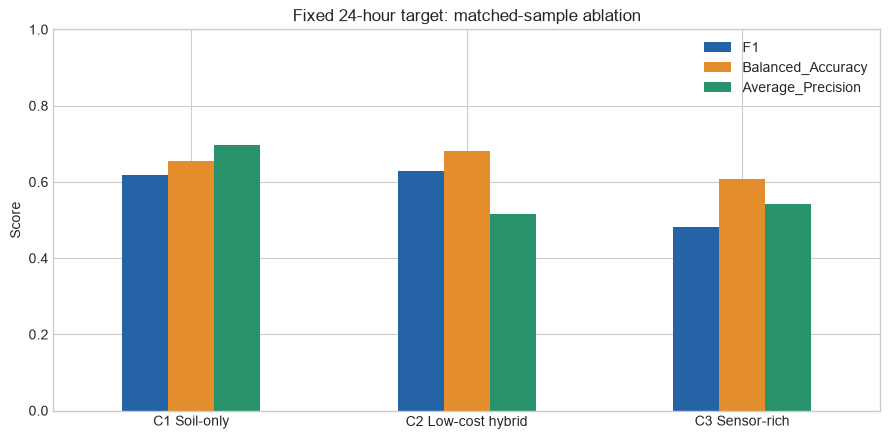

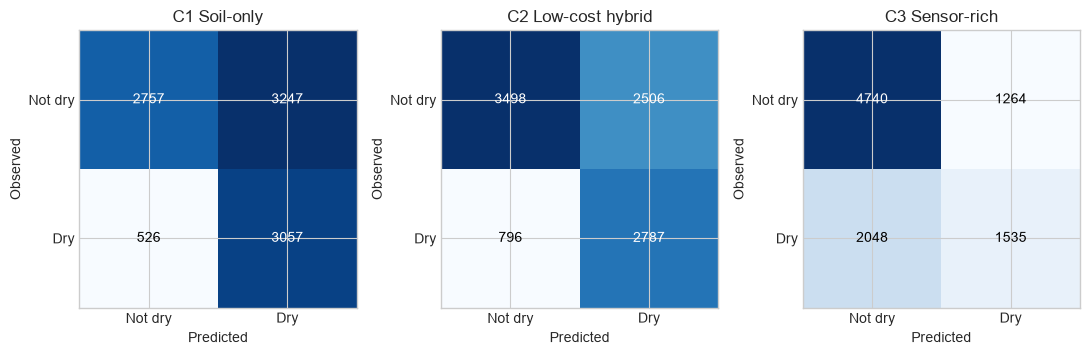

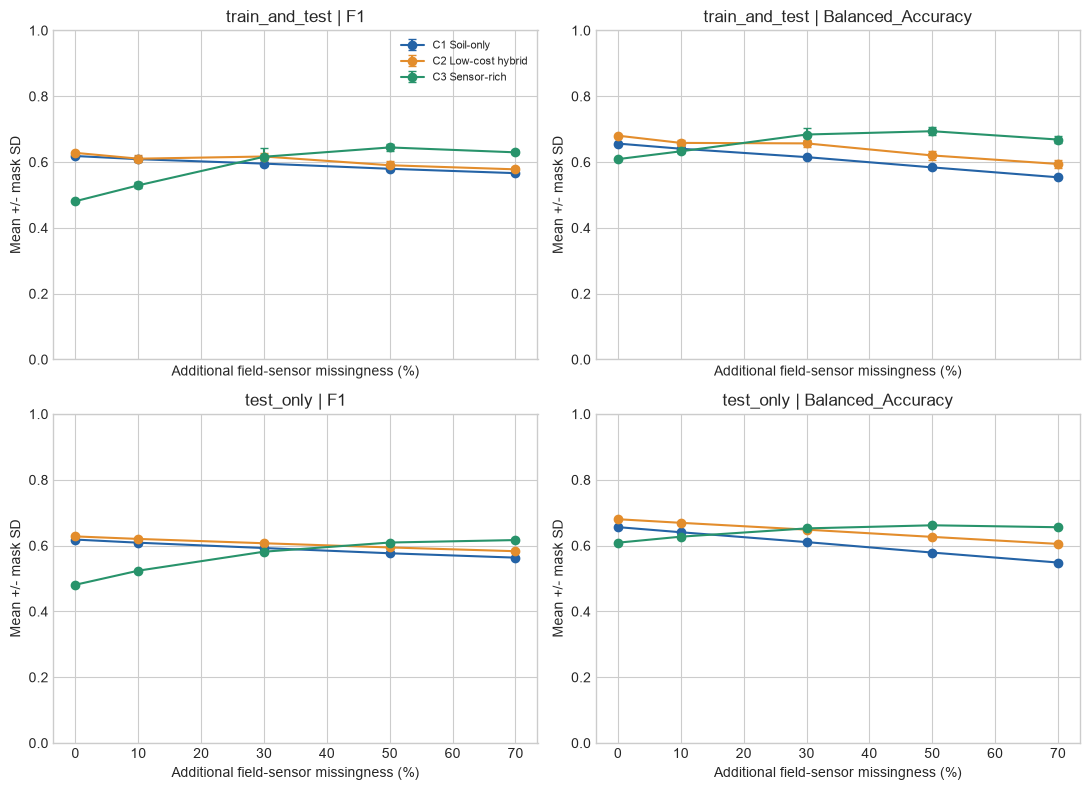

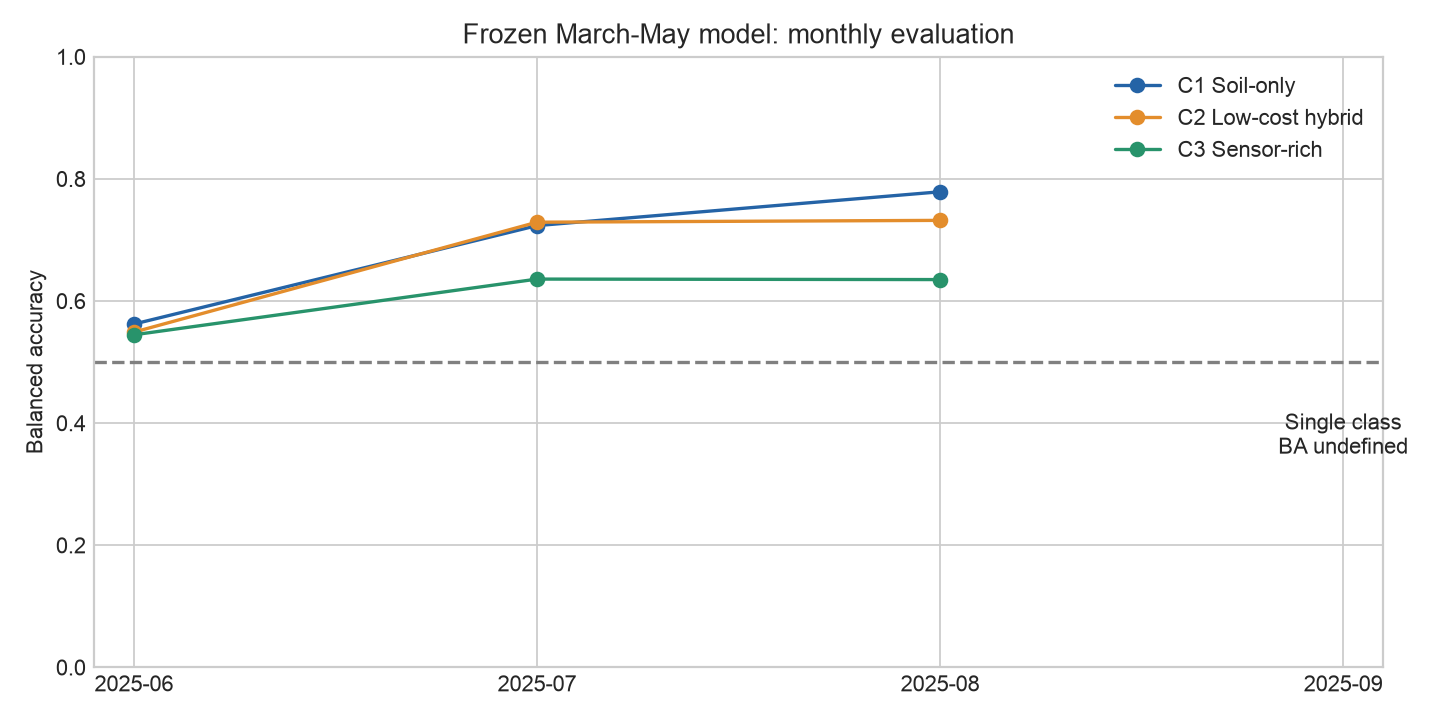

In [9]:
# 将实际指标保存成表图和中文结论，记录参数与数据来源。
plt.style.use('seaborn-v0_8-whitegrid')
v1_colors=['#2463a6','#e38d2c','#28936b']
fig,ax=plt.subplots(figsize=(9,4.5))
v1_ablation.set_index('configuration')[['F1','Balanced_Accuracy','Average_Precision']].plot.bar(ax=ax,color=v1_colors,rot=0)
ax.set_ylim(0,1); ax.set_title('Fixed 24-hour target: matched-sample ablation'); ax.set_ylabel('Score'); ax.set_xlabel('')
fig.tight_layout(); fig.savefig(v1_out/'ablation.png',dpi=160); plt.show()
fig,axes=plt.subplots(1,3,figsize=(11,3.5))
for ax,(_,r) in zip(axes,v1_ablation.iterrows()):
    cm=np.array([[r.TN,r.FP],[r.FN,r.TP]],dtype=int)
    ax.imshow(cm,cmap='Blues'); ax.set_title(r.configuration)
    ax.set_xticks([0,1],['Not dry','Dry']); ax.set_yticks([0,1],['Not dry','Dry'])
    ax.set_xlabel('Predicted'); ax.set_ylabel('Observed')
    for (i,j),v in np.ndenumerate(cm): ax.text(j,i,str(v),ha='center',va='center',color='white' if v>cm.max()/2 else 'black')
fig.tight_layout(); fig.savefig(v1_out/'confusion_matrices.png',dpi=160); plt.show()
fig,axes=plt.subplots(2,2,figsize=(11,8),sharex=True)
for row,scenario in enumerate(['train_and_test','test_only']):
    for col,metric in enumerate(['F1','Balanced_Accuracy']):
        ax=axes[row,col]
        for color,c in zip(v1_colors,v1_configs):
            g=v1_summary[(v1_summary.configuration==c)&(v1_summary.scenario==scenario)].sort_values('rate')
            ax.errorbar(g.rate*100,g[metric+'_mean'],yerr=g[metric+'_std'],marker='o',capsize=3,label=c,color=color)
        ax.set_title(scenario+' | '+metric); ax.set_ylim(0,1); ax.set_ylabel('Mean +/- mask SD'); ax.set_xlabel('Additional field-sensor missingness (%)')
axes[0,0].legend(fontsize=8); fig.tight_layout(); fig.savefig(v1_out/'missingness.png',dpi=160); plt.show()
fig,ax=plt.subplots(figsize=(9,4.5))
for color,c in zip(v1_colors,v1_configs):
    g=v1_temporal[v1_temporal.configuration==c]
    ax.plot(g.month,g.Balanced_Accuracy,marker='o',color=color,label=c)
ax.axhline(.5,color='gray',linestyle='--'); ax.set_ylim(0,1); ax.set_xticks(range(4), ['2025-06','2025-07','2025-08','2025-09']); ax.set_xlim(-.1,3.1); ax.text(3,.35,'Single class\nBA undefined',ha='center'); ax.set_title('Frozen March-May model: monthly evaluation'); ax.set_ylabel('Balanced accuracy'); ax.legend()
fig.tight_layout(); fig.savefig(v1_out/'temporal.png',dpi=160); plt.show()
v1_manifest={'protocol':'Research Technical Core v1','source_hashes':v1_hashes,
 'versions':{'python':platform.python_version(),'numpy':np.__version__,'pandas':pd.__version__,'sklearn':sklearn.__version__},
 'configs':v1_configs,'rf_params':v1_rf_params,'mask_seeds':v1_seeds,'mask_rates':v1_rates,
 'masked_features':v1_field,'target':'range-valid observed soil_moisture at decision+24 elapsed hours < zone threshold',
 'thresholds':v1_thresholds,'timezone':'Europe/Rome converted to UTC; nonexistent/ambiguous timestamps dropped',
 'train':'March-May; target before June 1','test':'June-July; target before August 1',
 'selection':'target available; same rows per configuration; input missingness imputed using training median',
 'flatline_rule':'same valid observed value for >=24h and >=12 observations; flag from detection onward, causal',
 'caveat':'Historical weather reanalysis/interpolation; retrospective research, not deployment validation',
 'elapsed_seconds':round(time.time()-v1_started,2)}
(v1_out/'run_manifest.json').write_text(json.dumps(v1_manifest,ensure_ascii=False,indent=2))
v1_known=[]
for _,r in v1_baselines.iterrows():
    v1_known.append(f"- 参照 {r.configuration}: F1={r.F1:.3f}, Balanced Accuracy={r.Balanced_Accuracy:.3f}, AP={r.Average_Precision:.3f}。")
for _,r in v1_ablation.iterrows():
    v1_known.append(f"- {r.configuration}: F1={r.F1:.3f}, Balanced Accuracy={r.Balanced_Accuracy:.3f}, AP={r.Average_Precision:.3f}, 预测正例率={r.predicted_positive_rate:.1%}。")
v1_report="""# Research Technical Core v1 — 实际运行结论

## Known（已核验）
- 旧 target 与清洗后后移144行一致；不能普遍解释为24小时。旧缺失曲线重复追加，不是两轮独立实验。
- 新核心以 UTC 精确24小时匹配有效观测标签，所有配置共享样本与标签；训练边界 purge，填补器仅 fit 训练数据。
"""+f'- 正式训练 {len(v1_train):,} 行，测试 {len(v1_test):,} 行；正例率分别 {v1_train.future_dry.mean():.1%}、{v1_test.future_dry.mean():.1%}。\n'+'\n'.join(v1_known)+"""

## Not Known（尚不能回答）
- 中国试点的阈值、灌溉时长、水量、节水收益、产量与作物安全效果。
- 哪个单独新增 feature 导致 C3 变化；需要后续逐项消融才能归因。
- 实际硬件成本与稳定性；尚未验证 BOM、设备通讯、真实连续故障。
- 跨农场、跨年泛化；历史结果不等于在线天气可用条件下的表现。

## Limitations（研究边界）
- 单农场、单季、分区阈值不同，RF 不输入 zone；标签是相对探头尺度，不等于通用含水率或缺水真值。
- 标签仅在未来传感器可用时存在，结果条件于该可用性；完整样本子集也有选择偏差。
- 范围过滤和因果24h不变值筛查仍不能排除所有漂移/尖峰，flatline筛查也可能误伤真实稳定状态；flatline_quality_audit.csv 记录剔除数量。时间聚合与历史天气插值不能证明在线因果可用性。
- 历史灌溉干预影响未来湿度，预测并非反事实灌溉需求。
- 10分钟样本和跨区天气高度相关；五次遮挡 SD 不是泛化置信区间，MCAR 不代表持续断网/MNAR。
- 主时间划分沿用既有研究探索，测试曾被查看；本版不调参，但不能称首次未见的独立验证。
- C3 混合天气服务、现场探头和操作日志；特征数量不是硬件数量或成本。
- 新旧数据清洗、目标、purge、mask定义均有变化，新旧分数变化不能单独归因于一个改动。

## 独立重跑
打开 research_core_v1.ipynb，重启内核后 Run All；或在项目内运行 src/research_core_v1.py。
依赖版本、源文件 SHA256、实验参数在 run_manifest.json；表格为 CSV，图为 PNG。
先核对 split_audit 和 fair_comparison_audit，再读 sensor_ablation/reference_baselines，最后读 missingness_summary 和 temporal_robustness。
本版完成的是可独立重跑的离线研究核心；硬件、Demo 与真实试点仍是后续工作。
"""
(v1_out/'Known_NotKnown_Limitations.md').write_text(v1_report)
print(v1_report)

## 本次运行结果怎么讲（2026-10-07）

- **复现对上了**：旧 ablation 的 F1 为 C1 0.4755、C2 0.2178、C3 0.2355，与原保存输出一致；截图缺失率 0% 的结果来自100棵树，不是这张200棵树的 ablation 表。原截图30行由15组重复追加产生。
- **正式问题已改正**：精确24小时目标、相同样本、训练边界 purge 和质量筛查后，训练5,923行，测试9,587行。新旧分数不能当作单一改动的“提升”。
- **主结果**：C1/C2/C3 的 F1 分别为0.618/0.628/0.481；Balanced Accuracy为0.656/0.680/0.609。C2略高于C1仅是这次切分的描述，没有显著性证据。AP反而C1较高，说明“谁最好”取决于评价目标。
- **重要参照**：当前状态延续的 F1=0.736、Balanced Accuracy=0.791，高于三种RF。它使用分区阈值；不能据此宣称严格同输入算法优劣，但足以阻止“复杂模型已验证有效”的过度结论。
- **样本选择敏感**：共同完整子集只有训练1,021行、测试5,345行，此时C1 F1=0.768，C2=0.478，C3=0.531。它们不可与主表直接比涨跌；样本群体改变了。
- **缺失不是简单单调降分**：train+test同时新增70%现场信息缺失时，五次F1均值约C1 0.566、C2 0.578、C3 0.630。C3部分指标上升只是这个遮挡/填补/分布组合下的现象，不能解释为断传感器更好，也不能据此选70%作部署方案。
- **时间变化明显**：6月正例率15.4%，7月46.0%；C2 Balanced Accuracy约0.549和0.729。9月剩余标签全为正例，Balanced Accuracy和PR指标记为NaN，不能用高F1证明双类识别稳定。
- **下一步方向**：先解释数据质量、当前状态参照与分区差异，再决定是否开展逐特征消融和真实试点采集；本版不继续堆模型。

### 你需要能独立回答的四个问题
1. 我们预测什么？——24小时后相对土壤读数是否低于该区历史阈值，不是直接预测中国地块该灌多少水。
2. 消融改变什么？——只换输入信息组，共同样本/标签/算法保持一致。
3. 缺失实验改变什么？——共同随机遮挡现场输入，标签不改，训练和测试缺失情境分开。
4. 什么时候不能下结论？——缺真值、只剩一种类别、疑似坏探头、跨农场迁移或因果节水效果都不能靠这张表证明。


## 8. 补查：探头“长时间不变”的筛查会不会改变结论？

刚才我们发现，Zone 3 有一大段读数一直是 0。为确认这条质量判断有没有左右主结果，我把实验做了两遍：

- 第一遍只剔除超出合理范围的读数。
- 第二遍还把连续一天、至少 12 次完全相同的读数标为“可能卡住”。

两遍的训练时间、测试日期、测试样本和正确答案都相同。结果：测试样本 **9,587 条**，两边答案完全一致；C1/C2/C3 的 F1 分别都是 **0.618、0.628、0.481**，Balanced Accuracy 分别都是 **0.656、0.680、0.609**。也就是说，**这条筛查没有改变本次 6–7 月总体结论**。

它标记最多的是 Zone 3：8,396 条；其他分区也有少量标记。说明数据质量问题真实存在，但不能单凭“数字重复”断定探头坏了。标记数字和逐配置对照表保存在项目的 results 文件夹中。

### 我们现在完成到哪里？

到这里，计划中的三类实验和这项清洗规则补查都完成了：比较三种信息组合、模拟传感器缺失、查看月份变化，并确认主结果不依赖本次长时间不变筛查。结论仍是：C2 在这次测试略高于 C1，C3 没有更好；简单的“明天大致跟今天一样”还比三种模型强。因此我们有了可信的第一版研究结果，但还不能说系统已经能指导田里的灌溉。

**怎么看结果**：下面代码会逐区输出被标记的条数和对照表。重新运行它只需运行这一格；完整重跑则运行上一节的 Research Technical Core v1。

In [1]:
# 运行质量筛查对照，并把表格显示在 notebook 里。
import runpy
from IPython.display import display
qc_sensitivity = runpy.run_path(r'/Users/kaylasun/Downloads/low-cost-irrigation/src/quality_screen_sensitivity.py')
display(qc_sensitivity['result'].round(4))


Shared test rows: 9587 same labels: True
Flagged readings by zone
screen  range_only  range_plus_flatline
zone                                   
1              188                  188
2              485                  485
3             8396                 8396
4              415                  415
5              339                  339
             screen      configuration  train_n  common_test_n  positive_rate     F1  balanced_accuracy     AP   TN   FP   FN   TP
         range_only       C1 Soil-only     5923           9587         0.3737 0.6184             0.6562 0.6978 2757 3247  526 3057
         range_only C2 Low-cost hybrid     5923           9587         0.3737 0.6280             0.6802 0.5162 3498 2506  796 2787
         range_only     C3 Sensor-rich     5923           9587         0.3737 0.4810             0.6089 0.5408 4740 1264 2048 1535
range_plus_flatline       C1 Soil-only     5923           9587         0.3737 0.6184             0.6562 0.6978 2757 3247  526 3057

,screen,configuration,train_n,common_test_n,positive_rate,F1,balanced_accuracy,AP,TN,FP,FN,TP
0,range_only,C1 Soil-only,5923,9587,0.3737,0.6184,0.6562,0.6978,2757,3247,526,3057
1,range_only,C2 Low-cost hybrid,5923,9587,0.3737,0.6280,0.6802,0.5162,3498,2506,796,2787
2,range_only,C3 Sensor-rich,5923,9587,0.3737,0.4810,0.6089,0.5408,4740,1264,2048,1535
3,range_plus_flatline,C1 Soil-only,5923,9587,0.3737,0.6184,0.6562,0.6978,2757,3247,526,3057
4,range_plus_flatline,C2 Low-cost hybrid,5923,9587,0.3737,0.6280,0.6802,0.5162,3498,2506,796,2787
5,range_plus_flatline,C3 Sensor-rich,5923,9587,0.3737,0.4810,0.6089,0.5408,4740,1264,2048,1535


## 9. 补查：C2 的领先可靠吗？模型胜过简单猜法吗？

**人话版**：C2 比 C1 的分数只高一点点。我们把测试日期按一周一组重复抽取 2,000 次，看看换一批测试周以后结果还稳不稳。

**结果**：C2 的 F1 平均只比 C1 高 0.004，可能的差异范围是 -0.032 到 +0.043；Balanced Accuracy 平均高 0.014，范围是 -0.031 到 +0.053。这两个范围都包含“没有差别”，所以现在不能说 C2 确实更好。

“明天跟今天差不多”的简单猜法，这次总分比三个模型高；但反复抽取测试周以后，范围很宽。现有 60 天不足以宣布哪一种在其他季节、其他地块也会赢。

分区差异很大：Zone 5 只有 20 个偏干样本，分数容易不稳定；Zone 2 有 1,311 个偏干样本，占本区测试记录的 85%。因此总分不能代表每个分区。

下面的表格可以逐区查看。重复抽样的区间只是帮助我们判断这次结果稳不稳，不是正式证明，也不能代表别的农场。

In [1]:
# 显示分区结果，以及“C2-C1”与“模型-简单猜法”的重复抽样差异。
from pathlib import Path
import pandas as pd
from IPython.display import display
v1_out = Path('/Users/kaylasun/Downloads/low-cost-irrigation/outputs/research_core_v1')
by_zone = pd.read_csv(v1_out / 'model_vs_persistence_by_zone.csv')
block_check = pd.read_csv(v1_out / 'model_comparison_block_bootstrap.csv')
display(by_zone.round(4))
display(block_check.round(4))


,scope,configuration,n,positive,positive_rate,F1,Balanced_Accuracy
0,Zone 1,C1 Soil-only,2603,1287,0.4944,0.7189,0.6248
1,Zone 1,C2 Low-cost hybrid,2603,1287,0.4944,0.7197,0.6769
2,Zone 1,C3 Sensor-rich,2603,1287,0.4944,0.3846,0.4940
3,Zone 1,Current-state persistence,2603,1287,0.4944,0.8170,0.8414
4,Zone 2,C1 Soil-only,1535,1311,0.8541,0.9227,0.5186
5,Zone 2,C2 Low-cost hybrid,1535,1311,0.8541,0.8917,0.6192
6,Zone 2,C3 Sensor-rich,1535,1311,0.8541,0.6751,0.6672
7,Zone 2,Current-state persistence,1535,1311,0.8541,0.8131,0.8169
8,Zone 3,C1 Soil-only,515,180,0.3495,0.5835,0.6223
9,Zone 3,C2 Low-cost hybrid,515,180,0.3495,0.6770,0.7445


,comparison,metric,mean,lower,upper,fraction_positive
0,C1 - persistence,Balanced_Accuracy,-0.0989,-0.2148,0.1220,0.1430
1,C1 - persistence,F1,-0.0728,-0.2480,0.2040,0.2100
2,C2 - C1,Balanced_Accuracy,0.0139,-0.0314,0.0526,0.7260
3,C2 - C1,F1,0.0044,-0.0316,0.0429,0.5790
4,C2 - persistence,Balanced_Accuracy,-0.0850,-0.2117,0.1237,0.1775
5,C2 - persistence,F1,-0.0684,-0.2554,0.2088,0.2415
6,C3 - persistence,Balanced_Accuracy,-0.1457,-0.2842,0.1144,0.1270
7,C3 - persistence,F1,-0.1975,-0.4183,0.2117,0.1380
